# Practica final NLP - Ejercicio 1
## Exploracion del corpus

Dataset: Amazon Reviews categoria **Digital_Music**.

En este notebook hacemos la exploracion basica del corpus y guardamos un
subset balanceado de 10.000 reviews que usaremos en el resto de notebooks.

## Librerias

In [1]:
import json
import string
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords

from wordcloud import WordCloud
from gensim.models import Word2Vec
from sklearn.manifold import TSNE

nltk.download('stopwords', quiet=True)

True

## 1. Cargar el dataset

De todos los campos del dataset nos quedaremos solamente con rating, title y text

In [2]:
path = 'Digital_Music.jsonl'

reviews = []
with open(path, 'r', encoding='utf-8') as f:
    for linea in f:
        d = json.loads(linea)
        reviews.append({
            'rating': d['rating'],
            'title': d.get('title', ''),
            'text': d.get('text', ''),
        })

df = pd.DataFrame(reviews)
print('Numero de reviews:', len(df))
df.head()

Numero de reviews: 130434


,rating,title,text
0,5.0,Nice,If i had a dollar for how many times I have pl...
1,5.0,Excellent,awesome sound - cant wait to see them in perso...
2,5.0,Great service,This is a great cd. Good music and plays well....
3,1.0,No good,"These are not real German singers, they have a..."
4,3.0,"Cool concept, so-so execution...",I first heard this playing in a Nagoya shop an...


## 2. Crear la etiqueta de sentimiento

- Positivo (1): rating >= 4
- Negativo (0): rating <= 2
- Las reviews con rating = 3 las eliminamos.

In [3]:
df = df[df['rating'] != 3]
df['sentiment'] = (df['rating'] >= 4).astype(int)
print(df['sentiment'].value_counts())

sentiment
1    114747
0      9295
Name: count, dtype: int64


## 3. Subset balanceado

Como el dataset tiene muchas más reviews positivas que negativas, escogeremos los datos balanceados, es ddecir, 5000 reviews positivas y 5000 negativas.


In [4]:
positivas = df[df['sentiment'] == 1].sample(5000, random_state=42)
negativas = df[df['sentiment'] == 0].sample(5000, random_state=42)

sub = pd.concat([positivas, negativas])
sub = sub.sample(frac=1, random_state=42).reset_index(drop=True)

print('Tamano del subset:', sub.shape)
print(sub['sentiment'].value_counts())

sub.to_csv('reviews_subset.csv', index=False)

Tamano del subset: (10000, 4)
sentiment
0    5000
1    5000
Name: count, dtype: int64


## 4. Distribucion de reviews por estrellas

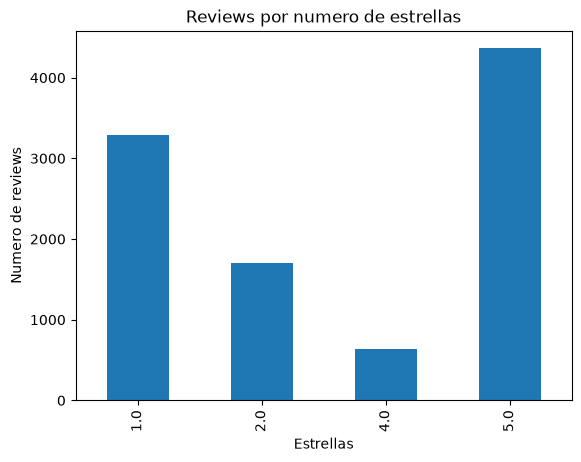

In [5]:
sub['rating'].value_counts().sort_index().plot(kind='bar')
plt.title('Reviews por numero de estrellas')
plt.xlabel('Estrellas')
plt.ylabel('Numero de reviews')
plt.show()

## 5. Numero de reviews positivas y negativas

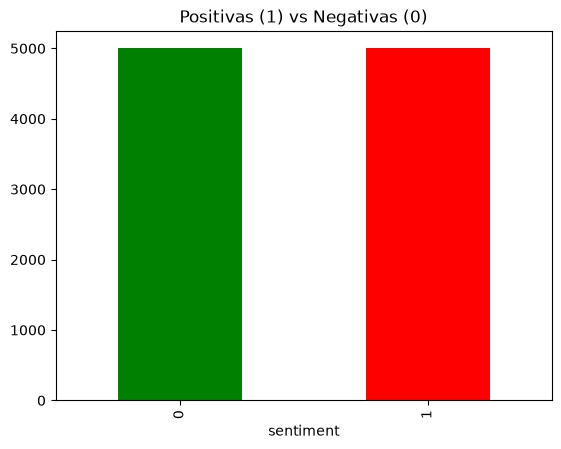

In [6]:
sub['sentiment'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Positivas (1) vs Negativas (0)')
plt.show()

## 6. Cardinalidad del vocabulario

Hacemos una limpieza muy basica (minusculas, sin puntuacion, sin stopwords)
solo para contar las palabras unicas.

In [ ]:
sw = set(stopwords.words('english'))
sw.add('br') 


def limpiar(texto):
    texto = texto.lower()
    for p in string.punctuation:
        texto = texto.replace(p, ' ')
    palabras = [w for w in texto.split() if w.isalpha() and w not in sw]
    return palabras

todas = []
for t in sub['text']:
    todas.extend(limpiar(t))

print('Total de palabras:', len(todas))
print('Palabras unicas (vocabulario):', len(set(todas)))

Total de palabras: 286412
Palabras unicas (vocabulario): 27797


## 7. N-grams mas frecuentes

[('cd', 4661), ('music', 2767), ('one', 2584), ('album', 2531), ('like', 2248), ('songs', 2213), ('great', 2023), ('good', 1699), ('love', 1606), ('song', 1339), ('sound', 1324), ('would', 1313), ('time', 1089), ('get', 1056), ('really', 998)]


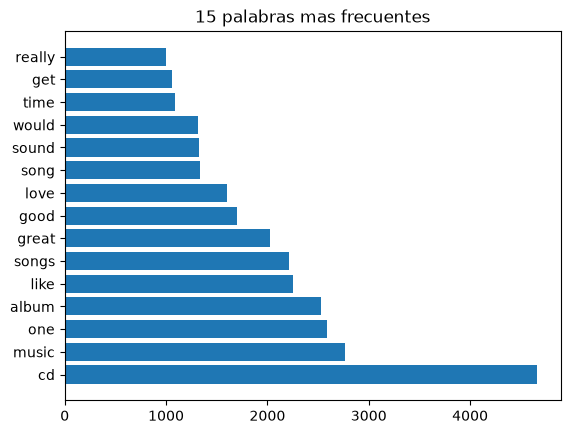

In [ ]:

freq = Counter(todas)
top = freq.most_common(15)
print(top)

palabras = []
valores = []
for palabra, veces in top:
    palabras.append(palabra)
    valores.append(veces)

plt.barh(palabras, valores)
plt.title('15 palabras mas frecuentes')
plt.show()

[('sound quality', 231), ('sounds like', 186), ('cd set', 134), ('buyer beware', 129), ('waste money', 128), ('years ago', 128), ('great cd', 112), ('sound like', 111), ('one best', 102), ('great album', 99), ('one song', 98), ('great music', 95), ('beware bootleg', 94), ('bootleg official', 93), ('official apple', 92)]


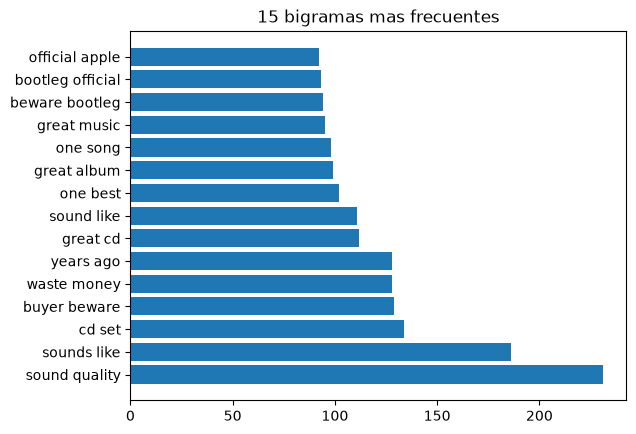

In [ ]:

bigramas = []
for t in sub['text']:
    p = limpiar(t)
    for i in range(len(p) - 1):
        pareja = p[i] + ' ' + p[i + 1]
        bigramas.append(pareja)

top_bg = Counter(bigramas).most_common(15)
print(top_bg)

etiquetas = []
valores = []
for pareja, veces in top_bg:
    etiquetas.append(pareja)
    valores.append(veces)

plt.barh(etiquetas, valores)
plt.title('15 bigramas mas frecuentes')
plt.show()

## 8. WordCloud

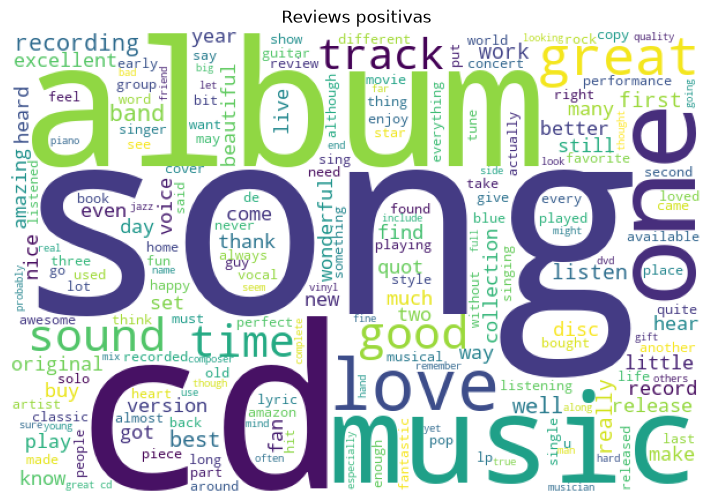

In [ ]:
#PALABRAS REVIEWS POSITTIVAS
palabras_pos = []
for t in sub[sub['sentiment'] == 1]['text']:
    palabras_pos.extend(limpiar(t))
texto_pos = ' '.join(palabras_pos)

wc = WordCloud(width=600, height=400, background_color='white').generate(texto_pos)
plt.figure(figsize=(10, 6))
plt.imshow(wc)
plt.axis('off')
plt.title('Reviews positivas')
plt.show()

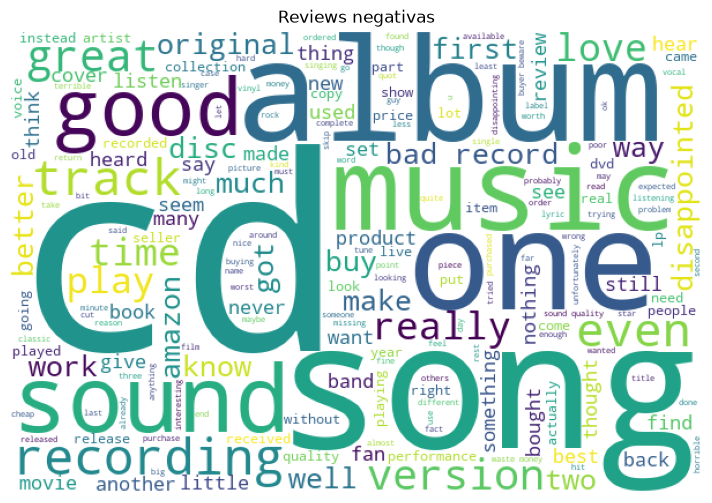

In [ ]:
#PALABRAS REVIEWS NEGATIVAS
palabras_neg = []
for t in sub[sub['sentiment'] == 0]['text']:
    palabras_neg.extend(limpiar(t))
texto_neg = ' '.join(palabras_neg)

wc = WordCloud(width=600, height=400, background_color='white').generate(texto_neg)
plt.figure(figsize=(10, 6))
plt.imshow(wc)
plt.axis('off')
plt.title('Reviews negativas')
plt.show()

## 9. Word2Vec

Entrenamos Word2Vec con gensim para obtener embeddings de palabras.

In [12]:
frases = []
for t in sub['text']:
    frases.append(limpiar(t))

w2v = Word2Vec(sentences=frases, vector_size=100, window=5, min_count=5, seed=42)
print('Vocabulario de Word2Vec:', len(w2v.wv.key_to_index))

for palabra in ['music', 'song', 'love', 'bad']:
    if palabra in w2v.wv:
        print(palabra, '->', w2v.wv.most_similar(palabra, topn=5))

Vocabulario de Word2Vec: 6635
music -> [('voice', 0.9902124404907227), ('beautiful', 0.9756903648376465), ('amazing', 0.965850830078125), ('wonderful', 0.965023398399353), ('hear', 0.964408814907074)]
song -> [('album', 0.9660036563873291), ('every', 0.9612248539924622), ('favorite', 0.9409117698669434), ('single', 0.92325359582901), ('beautiful', 0.9229162335395813)]
love -> [('every', 0.9750833511352539), ('listen', 0.9658198952674866), ('beautiful', 0.9638821482658386), ('favorite', 0.9589946866035461), ('loved', 0.9513713717460632)]
bad -> [('better', 0.9787340760231018), ('good', 0.9718208909034729), ('poor', 0.962318480014801), ('terrible', 0.9580954313278198), ('horrible', 0.9510248899459839)]


## 10. Visualizacion 2D de los embeddings (t-SNE)

Cogemos las palabras mas similares a 4 palabras y las pintamos en 2D.

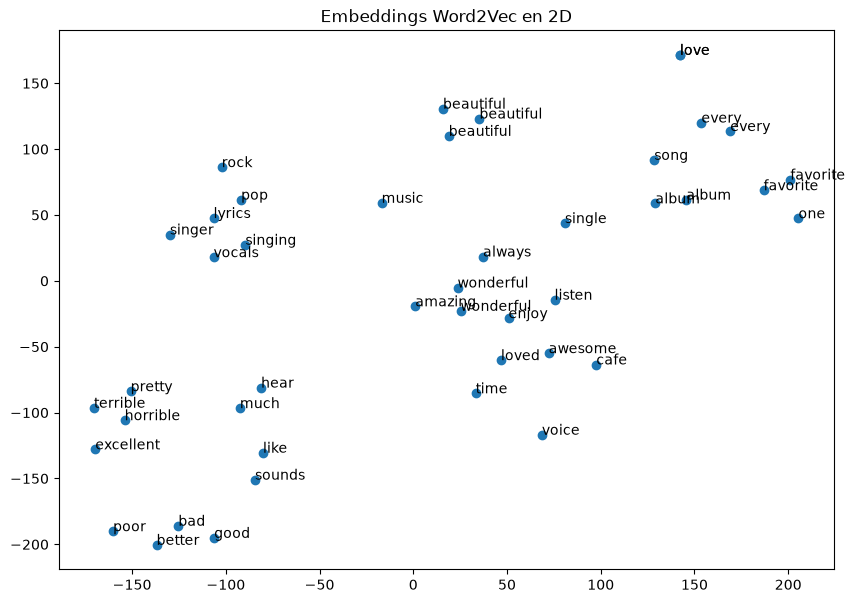

In [ ]:
claves = ['music', 'song', 'love', 'bad']
vectores = []
etiquetas = []

for palabra in claves:
    if palabra in w2v.wv:
        vectores.append(w2v.wv[palabra])
        etiquetas.append(palabra)
        similares = w2v.wv.most_similar(palabra, topn=10)
        for par in similares:
            palabra_similar = par[0]
            vectores.append(w2v.wv[palabra_similar])
            etiquetas.append(palabra_similar)

vectores = np.array(vectores)

tsne = TSNE(n_components=2, perplexity=5, random_state=42)
coords = tsne.fit_transform(vectores)

plt.figure(figsize=(10, 7))
plt.scatter(coords[:, 0], coords[:, 1])
for i in range(len(etiquetas)):
    plt.annotate(etiquetas[i], (coords[i, 0], coords[i, 1]))
plt.title('Embeddings Word2Vec en 2D')
plt.show()